# DGNet — Manifold10_MPS_aug — Setup + Prétraitement (notebook fusionné)

Fusion de `00-dgnet-modelnet10-project-setup` et `01-dgnet-modelnet10-original-preprocessing`
en un seul notebook, avec correction du bug d'isolation Jittor et ajout du diagnostic
topologique NetworkX.

## Étapes
1. Clonage du projet depuis GitHub (avec le sous-module DGNet officiel)
2. Connexion du dataset manifold10 (symlink)
3. Validation du projet et du dataset
4. Environnement Python isolé pour Jittor (venv)
5. Test de simplification géométrique (noyau principal, trimesh)
6. Construction de la pyramide DGNet (dans le venv isolé, via subprocess)
7. Diagnostic topologique NetworkX (desk / night_stand / sofa)


In [29]:
import os
from pathlib import Path

# 1. Recherche dynamique de la racine du dataset Manifold10_MPS_aug
dataset_root = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "manifold10_mps_aug" in root.lower():
        # Vérifie si ce dossier contient directement les sous-dossiers de classes (ex: car, door...)
        if any((Path(root) / d).is_dir() for d in dirs):
            dataset_root = Path(root)
            # On continue pour trouver le dossier le plus profond contenant la structure
            if any(
                (dataset_root / d / "train").exists() for d in os.listdir(dataset_root)
            ):
                break

# 2. Sécurité : si non trouvé dynamiquement, chemin direct basé sur la structure standard
if not dataset_root:
    candidates = list(Path("/kaggle/input").rglob("*Manifold10_MPS_aug*"))
    dataset_root = candidates[0] if candidates else None

# 3. Affichage du résultat et de la structure
if dataset_root and dataset_root.exists():
    print(f"✅ Chemin racine trouvé : {dataset_root}\n")

    print("--- Structure des classes et fichiers .obj ---")
    for item in sorted(dataset_root.iterdir()):
        if item.is_dir():
            train_objs = len(list((item / "train").glob("*.obj"))) if (item / "train").exists() else 0
            test_objs = len(list((item / "test").glob("*.obj"))) if (item / "test").exists() else 0
            
            if train_objs > 0 or test_objs > 0:
                print(f"📁 Classe '{item.name}' -> train: {train_objs} .obj | test: {test_objs} .obj")
            else:
                # Si le dossier contient directement d'autres sous-dossiers
                sub_dirs = [d.name for d in item.iterdir() if d.is_dir()]
                print(f"📁 Dossier '{item.name}' -> Sous-dossiers: {sub_dirs}")
else:
    print("❌ Dataset introuvable. Contenu actuel de /kaggle/input :")
    print(list(Path("/kaggle/input").iterdir()))

✅ Chemin racine trouvé : /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug

--- Structure des classes et fichiers .obj ---
📁 Classe 'bathtub' -> train: 636 .obj | test: 50 .obj
📁 Classe 'bowl' -> train: 384 .obj | test: 20 .obj
📁 Classe 'car' -> train: 1182 .obj | test: 100 .obj
📁 Classe 'door' -> train: 654 .obj | test: 20 .obj
📁 Classe 'guitar' -> train: 930 .obj | test: 100 .obj
📁 Classe 'keyboard' -> train: 870 .obj | test: 20 .obj
📁 Classe 'lamp' -> train: 744 .obj | test: 20 .obj
📁 Classe 'person' -> train: 528 .obj | test: 20 .obj
📁 Classe 'tent' -> train: 978 .obj | test: 20 .obj
📁 Classe 'xbox' -> train: 618 .obj | test: 20 .obj


In [30]:
from pathlib import Path

MANIFOLD10_AUG_ROOT = Path("/kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug")

print("Contenu direct :")
for p in sorted(MANIFOLD10_AUG_ROOT.iterdir()):
    print(" -", p)

Contenu direct :
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/bathtub
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/bowl
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/car
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/door
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/guitar
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/keyboard
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/lamp
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/person
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/tent
 - /kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug/xbox


In [31]:
from pathlib import Path

WORKING_ROOT = Path("/kaggle/working")
PROJECT_NAME = "3d-mesh-augmentation-study"
PROJECT_ROOT = WORKING_ROOT / PROJECT_NAME

GITHUB_URL = "https://github.com/Bilal51002/3d-mesh-augmentation-study.git"
GITHUB_BRANCH = "feat/dgnet-modelnet10-preprocessing"

EXPECTED_PROJECT_COMMIT = "92b5e8a"
EXPECTED_DGNET_COMMIT = "70abf402b58f7d44f0765c0436bfb03b53af4a5d"

EXPECTED_CLASSES = [
    "bathtub", "bed", "chair", "desk", "dresser",
    "monitor", "night_stand", "sofa", "table", "toilet",
]

EXPECTED_TRAIN_COUNT = 3991
EXPECTED_TEST_COUNT = 908
EXPECTED_TOTAL_COUNT = 4899

TARGET_FACE_COUNT = 1024
PYRAMID_LEVELS = 6

print("Project root :", PROJECT_ROOT)
print("Target faces :", TARGET_FACE_COUNT)


Project root : /kaggle/working/3d-mesh-augmentation-study
Target faces : 1024


## 1. Clonage du projet depuis GitHub

In [32]:
import os
import shutil
import subprocess

# Se replacer dans /kaggle/working AVANT toute suppression, pour ne jamais
# supprimer le repertoire dans lequel le kernel est physiquement positionne
# (sinon subprocess.run echoue avec "Unable to read current working directory").
os.chdir(WORKING_ROOT)

if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)

subprocess.run(
    [
        "git", "clone", "--recurse-submodules",
        "--branch", GITHUB_BRANCH,
        GITHUB_URL, str(PROJECT_ROOT),
    ],
    cwd=str(WORKING_ROOT),
    check=True,
)

print("✅ Projet cloné :", PROJECT_ROOT)


Cloning into '/kaggle/working/3d-mesh-augmentation-study'...
Submodule 'models/dgnet' (https://github.com/li-xl/DGNet.git) registered for path 'models/dgnet'
Cloning into '/kaggle/working/3d-mesh-augmentation-study/models/dgnet'...


Submodule path 'models/dgnet': checked out '70abf402b58f7d44f0765c0436bfb03b53af4a5d'
✅ Projet cloné : /kaggle/working/3d-mesh-augmentation-study


In [33]:
%cd /kaggle/working/3d-mesh-augmentation-study


/kaggle/working/3d-mesh-augmentation-study


In [34]:
!git branch --show-current
!git log -1 --oneline
!git submodule status


feat/dgnet-modelnet10-preprocessing
cf3dc4f (HEAD -> feat/dgnet-modelnet10-preprocessing, origin/feat/dgnet-modelnet10-preprocessing) Kaggle Notebook | 01-dgnet-modelnet10-setup-preprocessing-fusionne | Version 2
 70abf402b58f7d44f0765c0436bfb03b53af4a5d models/dgnet (heads/master)


## 2. Validation du projet

In [35]:
required_files = [
    PROJECT_ROOT / "adapters/dgnet/face_pool_compat.py",
    PROJECT_ROOT / "scripts/dgnet/create_manifests.py",
    PROJECT_ROOT / "scripts/dgnet/validate_manifests.py",
    PROJECT_ROOT / "scripts/dgnet/audit_modelnet10_meshes.py",
    PROJECT_ROOT / "scripts/dgnet/summarize_modelnet10_audit.py",
    PROJECT_ROOT / "scripts/dgnet/test_modelnet10_pyramid.py",
    PROJECT_ROOT / "scripts/dgnet/validate_modelnet10_classes.py",
    PROJECT_ROOT / "models/dgnet/jmesh/layers/face_pool.py",
]

missing_files = [p for p in required_files if not p.is_file()]

for path in required_files:
    status = "OK" if path.is_file() else "MANQUANT"
    print(f"{status:8} {path.relative_to(PROJECT_ROOT)}")

if missing_files:
    raise FileNotFoundError(f"Fichiers manquants : {missing_files}")

print("\n✅ Le code DGNet est complet.")


OK       adapters/dgnet/face_pool_compat.py
OK       scripts/dgnet/create_manifests.py
OK       scripts/dgnet/validate_manifests.py
OK       scripts/dgnet/audit_modelnet10_meshes.py
OK       scripts/dgnet/summarize_modelnet10_audit.py
OK       scripts/dgnet/test_modelnet10_pyramid.py
OK       scripts/dgnet/validate_modelnet10_classes.py
OK       models/dgnet/jmesh/layers/face_pool.py

✅ Le code DGNet est complet.


## 3. Environnement Python isolé pour Jittor

### Nettoyage (a executer avant chaque reconstruction du venv)


In [36]:
import shutil
from pathlib import Path

shutil.rmtree(WORKING_ROOT / "dgnet-jittor-env", ignore_errors=True)
shutil.rmtree(Path("/root/.cache/jittor"), ignore_errors=True)
print("Nettoyage terminé.")


Nettoyage terminé.


In [37]:
import sys

VENV_ROOT = WORKING_ROOT / "dgnet-jittor-env"
VENV_PYTHON = VENV_ROOT / "bin" / "python"
READY_MARKER = VENV_ROOT / ".dgnet_environment_ready"

REQUIRED_PACKAGES = [
    "numpy==1.26.4",
    "trimesh==4.12.2",
    "fast-simplification==0.1.13",
    "jittor==1.3.11.0",
    "tensorboardX==2.6.4",
    "plyfile",
    "pyyaml",
    "tqdm",
    "scipy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "psutil",
    "networkx",
    "open3d",
    "wrapt",
]

os.chdir(WORKING_ROOT)

# Jittor 1.3.11.0 crashes on Python >= 3.11 (confirmed in its source code:
# py_var_tracer.cc checks PY_MINOR_VERSION>=11 and aborts). Use Python 3.10
# for the isolated venv instead of the main kernel's Python 3.12.
python310_path = shutil.which("python3.10")
if python310_path is None:
    print("Python 3.10 introuvable, installation via apt...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "python3.10", "python3.10-venv", "python3.10-distutils", "python3.10-dev"],
        check=True,
    )
    python310_path = shutil.which("python3.10")

if python310_path is None:
    raise RuntimeError("Impossible d'installer Python 3.10.")

print("Python 3.10 trouve :", python310_path)

environment_ready = VENV_PYTHON.is_file() and READY_MARKER.is_file()

if not environment_ready:
    if VENV_ROOT.exists():
        shutil.rmtree(VENV_ROOT)

    print("1. Installation de virtualenv...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", "virtualenv"],
        cwd=WORKING_ROOT, check=True,
    )

    print("2. Création de l'environnement isolé (Python 3.10)...")
    subprocess.run(
        [sys.executable, "-m", "virtualenv", "--clear", "--python", python310_path, str(VENV_ROOT)],
        cwd=WORKING_ROOT, check=True,
    )

    if not VENV_PYTHON.is_file():
        raise FileNotFoundError(f"Python isolé introuvable : {VENV_PYTHON}")

    print("3. Installation des dépendances DGNet...")
    subprocess.run(
        [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-cache-dir",
         "--upgrade", "pip", "setuptools", "wheel"],
        cwd=WORKING_ROOT, check=True,
    )
    subprocess.run(
        [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-cache-dir", *REQUIRED_PACKAGES],
        cwd=WORKING_ROOT, check=True,
    )

    READY_MARKER.write_text("DGNet environment ready.\n", encoding="utf-8")
else:
    print("L'environnement isolé existe déjà. Installation ignorée.")

if not VENV_PYTHON.is_file():
    raise FileNotFoundError(f"Interpréteur introuvable : {VENV_PYTHON}")

print("\n✅ Environnement isolé prêt (Python 3.10)")
print("Python :", VENV_PYTHON)

Python 3.10 trouve : /usr/bin/python3.10
1. Installation de virtualenv...
2. Création de l'environnement isolé (Python 3.10)...
created virtual environment CPython3.10.12.final.0-64-x86_64 in 251ms
  creator CPython3Posix(dest=/kaggle/working/dgnet-jittor-env, clear=True, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, setuptools=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.2.1, setuptools==84.0.0
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator
3. Installation des dépendances DGNet...

✅ Environnement isolé prêt (Python 3.10)
Python : /kaggle/working/dgnet-jittor-env/bin/python


In [38]:
completed = subprocess.run(
    [str(VENV_PYTHON), "-c", "import site; print(site.getsitepackages()[0])"],
    capture_output=True, text=True, check=True,
)
VENV_SITE_PACKAGES = completed.stdout.strip()

VENV_ENV = os.environ.copy()
VENV_ENV["PYTHONPATH"] = VENV_SITE_PACKAGES
VENV_ENV.pop("PYTHONSTARTUP", None)

# FIX: utiliser le nvcc DEJA installé sur le système Kaggle, pour que Jittor
# n'essaie jamais de télécharger sa propre copie CUDA (serveur cg.cs.tsinghua.edu.cn cassé).
VENV_ENV["nvcc_path"] = "/usr/local/cuda/bin/nvcc"

# FIX: éviter les téléchargements MKL/oneDNN et cutlass (même cause réseau que CUDA).
VENV_ENV["use_mkl"] = "0"
VENV_ENV["use_cutlass"] = "0"


def run_in_venv(args, **kwargs):
    full_args = [str(VENV_PYTHON), "-S"] + list(args)
    kwargs.setdefault("env", VENV_ENV)
    kwargs.setdefault("cwd", WORKING_ROOT)
    return subprocess.run(full_args, **kwargs)


In [39]:
import importlib
import platform

modules_to_check = {
    "NumPy": "numpy", "SciPy": "scipy", "Pandas": "pandas",
    "Scikit-learn": "sklearn", "Trimesh": "trimesh",
    "TensorBoardX": "tensorboardX", "Jittor": "jittor",
    "Plyfile": "plyfile", "PyYAML": "yaml", "TQDM": "tqdm",
}

print("Environnement Python (noyau principal)")
print("Python   :", sys.version)
print("Platform :", platform.platform())
print()
for display_name, import_name in modules_to_check.items():
    try:
        module = importlib.import_module(import_name)
        version = getattr(module, "__version__", "version non exposée")
        print(f"{display_name:<16} ✅ {version}")
    except Exception as error:
        print(f"{display_name:<16} ❌ {type(error).__name__}: {error}")


Environnement Python (noyau principal)
Python   : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform : Linux-6.12.90+-x86_64-with-glibc2.35

NumPy            ✅ 2.0.2
SciPy            ✅ 1.16.3
Pandas           ✅ 2.3.3
Scikit-learn     ✅ 1.6.1
Trimesh          ✅ 5.1.0
TensorBoardX     ❌ ModuleNotFoundError: No module named 'tensorboardX'
Jittor           ❌ ModuleNotFoundError: No module named 'jittor'
Plyfile          ❌ ModuleNotFoundError: No module named 'plyfile'
PyYAML           ✅ 6.0.3
TQDM             ✅ 4.67.3


In [40]:
import os

real_path = "/usr/bin/x86_64-linux-gnu-python3.10-config"
link_path = "/usr/bin/python3.10-config"

if not os.path.exists(real_path):
    subprocess.run(["apt-get", "update", "-y"], check=True)
    subprocess.run(["apt-get", "install", "-y", "python3.10-dev"], check=True)

if not os.path.exists(link_path):
    os.symlink(real_path, link_path)
    print("Raccourci créé :", link_path, "->", real_path)
else:
    print("Déjà présent :", link_path)

check = subprocess.run([link_path, "--includes"], capture_output=True, text=True)
print("Test :", check.stdout, check.stderr)

Déjà présent : /usr/bin/python3.10-config
Test : -I/usr/include/python3.10 -I/usr/include/python3.10
 


In [41]:
import subprocess
from pathlib import Path

# 1. Installer cuDNN 8 ET cuBLAS 11 (dependance interne reelle de cuDNN 8.9.6 -
#    pas un conflit, le linker dynamique en a besoin comme fichier .so).
subprocess.run(
    [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-deps",
     "nvidia-cudnn-cu11==8.9.6.50", "nvidia-cublas-cu11"],
    check=True,
)

nvidia_root = VENV_ROOT / "lib/python3.10/site-packages/nvidia"
cudnn_lib_dir = nvidia_root / "cudnn" / "lib"
cudnn_include_dir = nvidia_root / "cudnn" / "include"
cublas_lib_dir = nvidia_root / "cublas" / "lib"
assert cudnn_lib_dir.is_dir() and cublas_lib_dir.is_dir(), "Paquets NVIDIA introuvables."

cuda_lib_dir = Path("/usr/local/cuda/lib64")
cuda_include_dir = Path("/usr/local/cuda/include")
cuda_lib_dir.mkdir(parents=True, exist_ok=True)
cuda_include_dir.mkdir(parents=True, exist_ok=True)

def link(src, dst):
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    dst.symlink_to(src)

created_libs, created_headers = [], []

# 2. Liens .so cuDNN (avec ET sans suffixe .8 - nvcc systeme est CUDA 12.x,
#    Jittor ne tente donc pas automatiquement le suffixe .8)
for so_file in cudnn_lib_dir.glob("*.so*"):
    link(so_file, cuda_lib_dir / so_file.name)
    created_libs.append(so_file.name)
    if so_file.name.endswith(".so.8"):
        link(so_file, cuda_lib_dir / so_file.name[:-2])
        created_libs.append(so_file.name[:-2])

# 3. Liens .so cuBLAS 11 (dependance interne de cuDNN 8)
for so_file in cublas_lib_dir.glob("*.so*"):
    link(so_file, cuda_lib_dir / so_file.name)
    created_libs.append(so_file.name)

# 4. En-tetes cuDNN 8 (remplacent les .h cuDNN 9 du systeme pour cette compilation)
for h_file in cudnn_include_dir.glob("*.h"):
    link(h_file, cuda_include_dir / h_file.name)
    created_headers.append(h_file.name)

print(f"{len(created_libs)} liens .so crees, {len(created_headers)} en-tetes crees.")

# 5. Verification
for r in ["libcudnn_ops_infer.so", "libcudnn_cnn_infer.so",
          "libcublasLt.so.11", "libcublas.so.11"]:
    p = cuda_lib_dir / r
    print(("OK " if p.exists() else "MANQUANT "), p)


17 liens .so crees, 18 en-tetes crees.
OK  /usr/local/cuda/lib64/libcudnn_ops_infer.so
OK  /usr/local/cuda/lib64/libcudnn_cnn_infer.so
OK  /usr/local/cuda/lib64/libcublasLt.so.11
OK  /usr/local/cuda/lib64/libcublas.so.11


In [42]:
MANIFOLD10_ROOT = Path("/kaggle/input/datasets/bilalkhallabi/manifold10-mps-aug/Manifold10_MPS_aug")
MANIFOLD10_CLASSES = sorted(p.name for p in MANIFOLD10_ROOT.iterdir() if p.is_dir())

print("Classes :", MANIFOLD10_CLASSES)
print("Nombre de classes :", len(MANIFOLD10_CLASSES))

# Regarder les fichiers dans une classe pour connaître le format
sample_class_dir = MANIFOLD10_ROOT / "bathtub" / "train"
sample_files = sorted(sample_class_dir.iterdir())[:10]
print("\nExemples de fichiers dans bathtub/train :")
for f in sample_files:
    print(" -", f.name)

train_files = list(MANIFOLD10_ROOT.glob("*/train/*"))
test_files = list(MANIFOLD10_ROOT.glob("*/test/*"))
# Filtrer uniquement les fichiers (pas les dossiers)
train_files = [f for f in train_files if f.is_file()]
test_files = [f for f in test_files if f.is_file()]

print("\nTrain :", len(train_files))
print("Test  :", len(test_files))
print("Total :", len(train_files) + len(test_files))

# Extensions presentes
extensions = set(f.suffix for f in train_files)
print("\nExtensions de fichiers :", extensions)


Classes : ['bathtub', 'bowl', 'car', 'door', 'guitar', 'keyboard', 'lamp', 'person', 'tent', 'xbox']
Nombre de classes : 10

Exemples de fichiers dans bathtub/train :
 - bathtub_0001-0.obj
 - bathtub_0001-1.obj
 - bathtub_0001-2.obj
 - bathtub_0001-3.obj
 - bathtub_0001-4.obj
 - bathtub_0001-5.obj
 - bathtub_0002-0.obj
 - bathtub_0002-1.obj
 - bathtub_0002-2.obj
 - bathtub_0002-3.obj

Train : 7524
Test  : 390
Total : 7914

Extensions de fichiers : {'.obj'}


In [43]:
%pip install --quiet trimesh

Note: you may need to restart the kernel to use updated packages.


In [44]:
import trimesh
import numpy as np

all_obj_files = train_files + test_files
face_counts = []
invalid_files = []

print("Audit de", len(all_obj_files), "fichiers...")

for obj_path in all_obj_files:
    try:
        mesh = trimesh.load(str(obj_path), process=False, maintain_order=True)
        if isinstance(mesh, trimesh.Scene):
            geometries = list(mesh.geometry.values())
            mesh = trimesh.util.concatenate(geometries) if geometries else None
        if mesh is None or len(mesh.faces) == 0:
            invalid_files.append(str(obj_path))
            continue
        face_counts.append(len(mesh.faces))
    except Exception as e:
        invalid_files.append(f"{obj_path} -> {e}")

face_counts = np.array(face_counts)
print("\nFichiers valides :", len(face_counts), "/", len(all_obj_files))
print("Fichiers invalides :", len(invalid_files))
if invalid_files:
    for f in invalid_files[:10]:
        print("  -", f)

print("\nFaces min/mean/median/max :", face_counts.min(), face_counts.mean(), np.median(face_counts), face_counts.max())
print("P90 :", np.percentile(face_counts, 90))
print("Uniforme :", face_counts.min() == face_counts.max())

Audit de 7914 fichiers...

Fichiers valides : 7914 / 7914
Fichiers invalides : 0

Faces min/mean/median/max : 496 509.29011877685116 500.0 3514
P90 : 500.0
Uniforme : False


In [45]:
manifold10_pilot_script_path = WORKING_ROOT / "run_manifold10_pilot.py"

manifold10_pilot_script_source = '''
import json
import sys
from pathlib import Path

import numpy as np
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
MANIFOLD10_ROOT = Path(sys.argv[2])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level

PYRAMID_LEVELS = 6
MANIFOLD10_CLASSES = sorted(p.name for p in MANIFOLD10_ROOT.iterdir() if p.is_dir())

results = {}

for class_name in MANIFOLD10_CLASSES:
    train_dir = MANIFOLD10_ROOT / class_name / "train"
    mesh_files = sorted(train_dir.glob("*.obj"))
    if not mesh_files:
        results[class_name] = {"status": "ERROR", "error": "no train files"}
        continue
    mesh_path = mesh_files[0]

    try:
        mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
        if isinstance(mesh, trimesh.Scene):
            geometries = list(mesh.geometry.values())
            mesh = trimesh.util.concatenate(geometries) if geometries else None

        faces = np.asarray(mesh.faces, dtype=np.int32)
        original_face_count = len(faces)

        levels = build_mesh_level(faces, level=PYRAMID_LEVELS)

        current_face_count = original_face_count
        for level_index, (pool_mask, adjacency) in enumerate(levels):
            pool_mask = np.asarray(pool_mask, dtype=np.int32)
            kept_faces = int(pool_mask.sum())
            if kept_faces <= 0:
                raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
            current_face_count = kept_faces

        results[class_name] = {
            "status": "OK", "original_faces": original_face_count,
            "final_faces": current_face_count, "mesh_file": mesh_path.name,
        }
    except Exception as error:
        results[class_name] = {
            "status": "ERROR", "error_type": type(error).__name__,
            "error_message": str(error),
        }

print(json.dumps(results, indent=2))
'''

manifold10_pilot_script_path.write_text(manifold10_pilot_script_source, encoding="utf-8")
print("Script écrit :", manifold10_pilot_script_path)

Script écrit : /kaggle/working/run_manifold10_pilot.py


In [46]:
process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(manifold10_pilot_script_path), str(PROJECT_ROOT), str(MANIFOLD10_ROOT)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0913 08:09:55.747478 16 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.
[i 0913 08:09:35.279396 56 lock.py:85] Create lock file:/root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x45/IntelRXeonRCPUx5a/9ee7/jittor.lock
[i 0913 08:09:35.290173 56 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0913 08:09:35.293171 56 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0913 08:09:35.293274 56 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x45/IntelRXeonRCPUx5a/9ee7/default
[i 0913 08:09:35.296707 56 compiler.py:900] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc
[i 0913 08:09:35.299879 56 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0913 08:09:35.423298 56 compiler.py:1012] cuda key:cu12.8.93_sm_60
[i 0913 08:09:35.456483 56 compiler.py:33] Create cache dir: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x45/IntelRXe

In [47]:
MANIFOLD10_OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "manifold10_preprocessed"
MANIFOLD10_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

manifold10_class_to_index = {name: index for index, name in enumerate(MANIFOLD10_CLASSES)}

manifold10_all_items = []
for class_name in MANIFOLD10_CLASSES:
    for split in ("train", "test"):
        split_dir = MANIFOLD10_ROOT / class_name / split
        for mesh_file in sorted(split_dir.glob("*.obj")):
            relative_output = Path(class_name) / split / f"{mesh_file.stem}.npz"
            manifold10_all_items.append({
                "input_path": str(mesh_file),
                "output_npz_path": str(MANIFOLD10_OUTPUT_ROOT / relative_output),
                "class_name": class_name,
                "class_index": manifold10_class_to_index[class_name],
                "split": split,
            })

print("Total de maillages à traiter :", len(manifold10_all_items))

manifold10_full_worker_script_path = WORKING_ROOT / "run_manifold10_full_preprocessing.py"

manifold10_full_worker_script_source = '''
import json
import sys
import traceback
from pathlib import Path

import numpy as np
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
INPUT_JSON = Path(sys.argv[2])
OUTPUT_JSON = Path(sys.argv[3])
PYRAMID_LEVELS = int(sys.argv[4])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level


def process_one(item):
    mesh_path = Path(item["input_path"])
    output_npz_path = Path(item["output_npz_path"])

    mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(mesh, trimesh.Scene):
        geometries = list(mesh.geometry.values())
        if not geometries:
            raise RuntimeError("Le fichier ne contient aucune geometrie.")
        mesh = trimesh.util.concatenate(geometries)

    vertices = np.asarray(mesh.vertices, dtype=np.float32)
    faces = np.asarray(mesh.faces, dtype=np.int32)
    original_face_count = len(faces)

    if len(faces) == 0:
        raise ValueError("Aucune face dans le maillage.")

    levels = build_mesh_level(faces, level=PYRAMID_LEVELS)

    pool_masks = []
    adjacencies = []
    current_face_count = original_face_count
    for level_index, (pool_mask, adjacency) in enumerate(levels):
        pool_mask = np.asarray(pool_mask, dtype=np.int32)
        adjacency = np.asarray(adjacency, dtype=np.int32)
        kept_faces = int(pool_mask.sum())
        if len(pool_mask) != current_face_count:
            raise RuntimeError(f"Niveau {level_index} : masques incoherents.")
        if kept_faces <= 0:
            raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
        pool_masks.append(pool_mask)
        adjacencies.append(adjacency)
        current_face_count = kept_faces

    output_npz_path.parent.mkdir(parents=True, exist_ok=True)
    save_dict = {
        "vertices": vertices,
        "faces": faces,
        "class_name": item["class_name"],
        "class_index": item["class_index"],
        "split": item["split"],
    }
    for level_index, (pool_mask, adjacency) in enumerate(zip(pool_masks, adjacencies)):
        save_dict[f"level_{level_index}_pool_mask"] = pool_mask
        save_dict[f"level_{level_index}_adjacency"] = adjacency
    np.savez_compressed(output_npz_path, **save_dict)

    return {
        "input_path": str(mesh_path),
        "output_npz_path": str(output_npz_path),
        "class_name": item["class_name"],
        "split": item["split"],
        "status": "OK",
        "original_faces": original_face_count,
        "final_faces": current_face_count,
    }


def main():
    items = json.loads(INPUT_JSON.read_text(encoding="utf-8"))
    results = []
    for item in items:
        try:
            result = process_one(item)
        except Exception as error:
            result = {
                "input_path": item["input_path"],
                "output_npz_path": item["output_npz_path"],
                "class_name": item["class_name"],
                "split": item["split"],
                "status": "ERROR",
                "error_type": type(error).__name__,
                "error_message": str(error),
                "traceback": traceback.format_exc(),
            }
        results.append(result)

    OUTPUT_JSON.write_text(json.dumps(results), encoding="utf-8")


if __name__ == "__main__":
    main()
'''

manifold10_full_worker_script_path.write_text(manifold10_full_worker_script_source, encoding="utf-8")
print("Script écrit :", manifold10_full_worker_script_path)

Total de maillages à traiter : 7914
Script écrit : /kaggle/working/run_manifold10_full_preprocessing.py


In [48]:
import json
import time

manifold10_all_results = []
manifold10_input_json_path = WORKING_ROOT / "manifold10_preprocessing_input.json"
manifold10_output_json_path = WORKING_ROOT / "manifold10_preprocessing_output.json"

overall_started_at = time.perf_counter()

for class_index, class_name in enumerate(MANIFOLD10_CLASSES):
    class_items = [item for item in manifold10_all_items if item["class_name"] == class_name]

    manifold10_input_json_path.write_text(json.dumps(class_items), encoding="utf-8")

    class_started_at = time.perf_counter()
    completed = run_in_venv(
        [
            str(manifold10_full_worker_script_path),
            str(PROJECT_ROOT), str(manifold10_input_json_path), str(manifold10_output_json_path),
            str(PYRAMID_LEVELS),
        ],
        capture_output=True,
        text=True,
    )
    class_elapsed = time.perf_counter() - class_started_at

    if completed.returncode != 0:
        print(completed.stdout)
        print(completed.stderr)
        raise RuntimeError(f"Le lot '{class_name}' a echoue (code {completed.returncode}).")

    class_results = json.loads(manifold10_output_json_path.read_text(encoding="utf-8"))
    manifold10_all_results.extend(class_results)

    success_count = sum(1 for r in class_results if r["status"] == "OK")
    print(f"[{class_index + 1:>2}/10] {class_name:<12} "
          f"{success_count}/{len(class_results)} OK  ({class_elapsed:.1f} s)")

overall_elapsed = time.perf_counter() - overall_started_at
print(f"\n✅ Terminé en {overall_elapsed / 60:.1f} min — {len(manifold10_all_results)}/{len(manifold10_all_items)} maillages traités.")

[ 1/10] bathtub      686/686 OK  (8.2 s)
[ 2/10] bowl         404/404 OK  (5.6 s)
[ 3/10] car          1282/1282 OK  (13.4 s)
[ 4/10] door         674/674 OK  (8.2 s)
[ 5/10] guitar       1030/1030 OK  (11.1 s)
[ 6/10] keyboard     890/890 OK  (9.8 s)
[ 7/10] lamp         764/764 OK  (9.3 s)
[ 8/10] person       548/548 OK  (6.9 s)
[ 9/10] tent         998/998 OK  (11.0 s)
[10/10] xbox         638/638 OK  (7.6 s)

✅ Terminé en 1.5 min — 7914/7914 maillages traités.


In [49]:
modelnet10_dataset_script = '''
import numpy as np
import trimesh
from jittor.dataset import Dataset

from jmesh.data.tensor import MeshTensor
from jmesh.utils.general import to_jt_var


def normalize_vertices(vertices):
    """Centre le maillage sur son centroide et le met a l'echelle dans une
    sphere unite (distance max a l'origine = 1). Necessaire car DGNet utilise
    une taille de voxel fixe (vsize=0.1) pour regrouper les faces voisines
    (sample_vbuffer) -- sans normalisation, un maillage a une echelle brute
    differente fait exploser le nombre de voxels necessaires."""
    centered = vertices - vertices.mean(axis=0, keepdims=True)
    scale = np.max(np.linalg.norm(centered, axis=1))
    if scale < 1e-8:
        scale = 1.0
    return (centered / scale).astype(np.float32)


def compute_face_features(vertices, faces):
    """Reproduit load_feature() de jmesh/data/scannet.py, sans le canal
    couleur (non pertinent pour ModelNet10, sans texture)."""
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)

    FN = mesh.face_normals
    VN = mesh.vertex_normals
    area = mesh.area_faces[:, None]

    FV = vertices[faces.flatten()].reshape(-1, 3, 3)
    center = FV.mean(axis=1)

    curvs = np.hstack([
        (VN[faces[:, 0]] * FN).sum(axis=1, keepdims=True),
        (VN[faces[:, 1]] * FN).sum(axis=1, keepdims=True),
        (VN[faces[:, 2]] * FN).sum(axis=1, keepdims=True),
    ])
    curvs = np.sort(curvs, axis=1)
    angles = np.sort(mesh.face_angles, axis=1)

    feature = np.concatenate([area, FN, center, angles, curvs], axis=1)
    return feature.T.astype(np.float32), center.astype(np.float32)


class ModelNet10Classification(Dataset):
    def __init__(self, dataroot, class_names, split="train",
                 batch_size=4, shuffle=False, num_workers=0,
                 pyramid_levels=6, drop_last=False):
        super().__init__(batch_size=batch_size, shuffle=shuffle,
                          num_workers=num_workers, drop_last=drop_last)
        assert split in ("train", "test")
        self.dataroot = dataroot
        self.class_names = class_names
        self.class_to_index = {name: i for i, name in enumerate(class_names)}
        self.split = split
        self.pyramid_levels = pyramid_levels

        self.files = []
        for class_name in class_names:
            self.files.extend(sorted((dataroot / class_name / split).glob("*.npz")))
        self.total_len = len(self.files)

    def __getitem__(self, idx):
        npz_path = self.files[idx]
        data = np.load(npz_path)

        vertices = normalize_vertices(data["vertices"])
        faces = data["faces"]
        class_index = int(data["class_index"])

        feature, centers = compute_face_features(vertices, faces)
        Fs = faces.shape[0]

        levels = []
        for level_index in range(self.pyramid_levels):
            pool_mask = data[f"level_{level_index}_pool_mask"]
            adjacency = data[f"level_{level_index}_adjacency"]
            levels.append((pool_mask, adjacency))

        return feature, Fs, levels, class_index, centers, str(npz_path)

    def collate_batch(self, batch):
        feats, Fs, levels, labels, centers, files = zip(*batch)
        N = len(batch)
        max_f = max(Fs)

        np_feats = np.zeros((N, feats[0].shape[0], max_f), dtype=np.float32)
        for i in range(N):
            np_feats[i, :, :Fs[i]] = feats[i]

        np_levels = self.collate_levels(levels, centers)
        np_labels = np.array(labels, dtype=np.int32)

        feats_t, levels_t, labels_t = to_jt_var([np_feats, np_levels, np_labels])

        mesh_tensor = MeshTensor(feats=feats_t, level=0, levels=levels_t, mesh_files=files)
        return mesh_tensor, labels_t

    def collate_levels(self, levels, centers):
        levels = list(zip(*levels))
        L = len(levels)
        N = len(levels[0])
        Fs = []
        for i in range(L):
            F = [len(levels[i][j][0]) for j in range(N)]
            Fs.append(np.array(F, dtype=np.int32))

        np_levels = []
        current_centers = list(centers)
        for i in range(L):
            max_f = Fs[i].max().item()
            np_pool_mask = np.zeros((N, max_f), dtype=np.int32)
            np_adj = -np.ones((N, max_f, 3), dtype=np.int32)
            np_center = []
            new_centers = []
            for j, (pool_mask, adj) in enumerate(levels[i]):
                np_pool_mask[j, :Fs[i][j]] = pool_mask
                np_adj[j, :Fs[i][j], :] = adj
                np_center.append(current_centers[j])
                n_c = current_centers[j][pool_mask == 1]
                new_centers.append(n_c)
            current_centers = new_centers
            np_indexes = (np_pool_mask.cumsum(1) * np_pool_mask) - 1
            np_levels.append((np_pool_mask, np_adj, Fs[i], np_center, np_indexes))
        return np_levels
'''

dataset_module_path = PROJECT_ROOT / "adapters" / "dgnet" / "modelnet10_dataset.py"
dataset_module_path.write_text(modelnet10_dataset_script, encoding="utf-8")
print("Écrit :", dataset_module_path)

Écrit : /kaggle/working/3d-mesh-augmentation-study/adapters/dgnet/modelnet10_dataset.py


In [50]:
classifier_model_script = '''
from jittor import nn
import jittor as jt

from jmesh.models.dgnet import MLP, SpatialBlock, MeshPool, MeshLinear, MeshDropout


class DGNetClassifier(nn.Module):
    """Encodeur DGNet (sans decodeur) + pooling global + tete FC.
    Le depot officiel DGNet ne propose que la segmentation par face (ScanNet) ;
    cette tete de classification est une adaptation pour ModelNet10 (voir
    cahier des charges, section 5.1 - modifications documentees)."""

    def __init__(self,
                 in_channels=13,
                 encoder_channels=[32, 64, 96, 128, 128],
                 dilations=[1, 1, 1, 1],
                 radius=[None, 0.2, 0.4, 0.8],
                 max_sample=30,
                 temp_sample=1000,
                 merge_op="max",
                 num_classes=10,
                 cls_dropout=0.5):
        super().__init__()

        self.block1 = nn.Sequential([
            MLP(in_channels, encoder_channels[0], with_bn=False),
            SpatialBlock(encoder_channels[0], encoder_channels[0]),
        ])

        self.pool = MeshPool(op="max")
        self.depth = len(encoder_channels) - 1

        self.encoders = nn.Sequential()
        for i in range(self.depth):
            self.encoders.append(
                SpatialBlock(
                    encoder_channels[i], encoder_channels[i + 1],
                    dilation=dilations[i], radius=radius[i],
                    max_sample=max_sample, temp_sample=temp_sample,
                    merge_op=merge_op,
                )
            )

        final_channels = encoder_channels[-1]
        self.classifier_head = nn.Sequential([
            nn.Linear(final_channels, final_channels // 2),
            nn.ReLU(),
            nn.Dropout(cls_dropout),
            nn.Linear(final_channels // 2, num_classes),
        ])

    def execute(self, mesh):
        mesh = self.block1(mesh)

        for i in range(self.depth):
            mesh = self.pool(mesh)
            mesh = self.encoders[i](mesh)

        # Pooling global (max) sur les faces restantes -> un vecteur par maillage.
        global_feature = mesh.feats.max(dim=-1)
        logits = self.classifier_head(global_feature)
        return logits
'''

classifier_module_path = PROJECT_ROOT / "adapters" / "dgnet" / "modelnet10_classifier.py"
classifier_module_path.write_text(classifier_model_script, encoding="utf-8")
print("Écrit :", classifier_module_path)

Écrit : /kaggle/working/3d-mesh-augmentation-study/adapters/dgnet/modelnet10_classifier.py


In [51]:
manifold10_training_script_path = WORKING_ROOT / "run_manifold10_training.py"

manifold10_training_script_source = '''
import sys
import time
import json
import csv
from pathlib import Path

import jittor as jt
import numpy as np

PROJECT_ROOT = Path(sys.argv[1])
PREPROCESSED_ROOT = Path(sys.argv[2])
OUTPUT_DIR = Path(sys.argv[3])

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "models" / "dgnet"))
from adapters.dgnet.modelnet10_dataset import ModelNet10Classification
from adapters.dgnet.modelnet10_classifier import DGNetClassifier

from jmesh.models.dgnet import SpatialConv, sample_spatialface, dilated_face_adjacencies, sample_adj


def patched_spatialconv_execute(self, mesh):
    """Remplace SpatialConv.execute officiel : conv_sf remplace par matmul
    (contournement cuDNN, voir cahier des charges §5.1)."""
    feats = mesh.feats
    Fs = mesh.Fs
    f1 = self.conv_f(feats)

    if self.kernel_size == 3:
        f2 = self.conv_mf(feats)
        adj = mesh.face_adjacency
        adj = dilated_face_adjacencies(adj, self.dilation)
        f2 = sample_adj(f2, adj, Fs, self.merge_op)
    else:
        f2 = 0.

    if self.with_spatial:
        sample_size = 5
        adj_feats = sample_spatialface(mesh, dilation=self.spatial_dilation, sample_size=sample_size)
        weight = self.conv_sf.weight
        N_, Cin_, F_, sd_ = adj_feats.shape
        out_channels_ = weight.shape[0]
        w_flat = weight.reshape(out_channels_, Cin_ * sd_)
        x_flat = adj_feats.permute(0, 2, 1, 3).reshape(N_, F_, Cin_ * sd_)
        f3 = jt.matmul(x_flat, w_flat.transpose(1, 0))
        f3 = f3.permute(0, 2, 1)
    else:
        f3 = 0.

    ff = [f1]
    if isinstance(f2, jt.Var):
        ff.append(f2)
    if isinstance(f3, jt.Var):
        ff.append(f3)

    feats = sum(ff)
    attn_c = self.se(feats.mean(dim=-1))
    feats = attn_c[:, :, None] * feats

    return mesh.updated(feats=feats)


SpatialConv.execute = patched_spatialconv_execute
print("SpatialConv.execute patche (conv_sf remplace par matmul, contournement cuDNN)")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
jt.set_seed(RANDOM_SEED)

jt.flags.use_cuda = 1 if jt.has_cuda else 0
print("CUDA disponible :", bool(jt.has_cuda), "-> use_cuda =", jt.flags.use_cuda)

CLASS_NAMES = [
    "bathtub", "bowl", "car", "door", "guitar",
    "keyboard", "lamp", "person", "tent", "xbox",
]

BATCH_SIZE = 4
NUM_EPOCHS = 150
LEARNING_RATE = 1e-3
LR_STEP_SIZE = 30
LR_GAMMA = 0.5
WEIGHT_DECAY = 1e-4
CHECKPOINT_EVERY = 10

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
checkpoints_dir = OUTPUT_DIR / "checkpoints"
checkpoints_dir.mkdir(exist_ok=True)

train_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="train",
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)
test_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="test",
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

print(f"Train : {len(train_dataset.files)} maillages")
print(f"Test  : {len(test_dataset.files)} maillages")

model = DGNetClassifier(in_channels=13, num_classes=len(CLASS_NAMES), cls_dropout=0.3)
optimizer = jt.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = jt.nn.CrossEntropyLoss()

history = []
best_test_acc = 0.
best_epoch = 0
training_started_at = time.perf_counter()

for epoch in range(NUM_EPOCHS):
    epoch_started_at = time.perf_counter()

    current_lr = LEARNING_RATE * (LR_GAMMA ** (epoch // LR_STEP_SIZE))
    optimizer.lr = current_lr

    model.train()
    total_loss = 0.
    total_correct = 0
    total_seen = 0

    for mesh_tensor, labels in train_dataset:
        logits = model(mesh_tensor)
        loss = criterion(logits, labels)
        optimizer.step(loss)

        predictions = logits.argmax(dim=1)[0]
        total_correct += (predictions == labels).sum().item()
        total_seen += labels.shape[0]
        total_loss += loss.item() * labels.shape[0]

    train_loss = total_loss / max(total_seen, 1)
    train_acc = total_correct / max(total_seen, 1)

    model.eval()
    test_correct = 0
    test_seen = 0
    for mesh_tensor, labels in test_dataset:
        logits = model(mesh_tensor)
        predictions = logits.argmax(dim=1)[0]
        test_correct += (predictions == labels).sum().item()
        test_seen += labels.shape[0]

    test_acc = test_correct / max(test_seen, 1)
    epoch_elapsed = time.perf_counter() - epoch_started_at

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - lr={current_lr:.6f} "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
          f"test_acc={test_acc:.3f} ({epoch_elapsed:.1f}s)")

    history.append({
        "epoch": epoch + 1, "lr": current_lr, "train_loss": train_loss,
        "train_acc": train_acc, "test_acc": test_acc, "elapsed_seconds": epoch_elapsed,
    })

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        model.save(str(checkpoints_dir / "best_model.pkl"))

    if (epoch + 1) % CHECKPOINT_EVERY == 0:
        model.save(str(checkpoints_dir / f"epoch_{epoch + 1}.pkl"))

model.save(str(checkpoints_dir / "final_model.pkl"))
total_training_time = time.perf_counter() - training_started_at

with open(OUTPUT_DIR / "training_history.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "lr", "train_loss", "train_acc", "test_acc", "elapsed_seconds"])
    writer.writeheader()
    writer.writerows(history)

model.load(str(checkpoints_dir / "best_model.pkl"))
model.eval()

all_predictions = []
all_labels = []
for mesh_tensor, labels in test_dataset:
    logits = model(mesh_tensor)
    predictions = logits.argmax(dim=1)[0]
    all_predictions.extend(predictions.numpy().tolist())
    all_labels.extend(labels.numpy().tolist())

np.savez(
    OUTPUT_DIR / "final_predictions.npz",
    predictions=np.array(all_predictions), labels=np.array(all_labels),
    class_names=np.array(CLASS_NAMES),
)

training_info = {
    "num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE, "optimizer": "Adam",
    "learning_rate": LEARNING_RATE, "lr_scheduler": f"StepLR(step={LR_STEP_SIZE}, gamma={LR_GAMMA})",
    "weight_decay": WEIGHT_DECAY, "loss_function": "CrossEntropyLoss",
    "hardware": "Kaggle GPU (via jittor)", "cuda_enabled": bool(jt.flags.use_cuda),
    "random_seed": RANDOM_SEED, "best_epoch": best_epoch, "best_test_acc": best_test_acc,
    "total_training_time_seconds": total_training_time,
    "train_size": len(train_dataset.files), "test_size": len(test_dataset.files),
    "dataset": "manifold10", "num_classes": len(CLASS_NAMES),
}
with open(OUTPUT_DIR / "training_info.json", "w", encoding="utf-8") as f:
    json.dump(training_info, f, indent=2)

print(f"\\n✅ Entraînement termine en {total_training_time / 60:.1f} min.")
print(f"Meilleure test_acc : {best_test_acc:.3f} (epoch {best_epoch})")
print("Résultats sauvegardés dans :", OUTPUT_DIR)
'''

manifold10_training_script_path.write_text(manifold10_training_script_source, encoding="utf-8")
print("Script écrit :", manifold10_training_script_path)

Script écrit : /kaggle/working/run_manifold10_training.py


In [52]:
MANIFOLD10_TRAINING_OUTPUT_DIR = WORKING_ROOT / "manifold10_training_output"

process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(manifold10_training_script_path), str(PROJECT_ROOT), str(MANIFOLD10_OUTPUT_ROOT), str(MANIFOLD10_TRAINING_OUTPUT_DIR)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0913 08:13:53.891070 96 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0913 08:13:53.894050 96 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0913 08:13:53.894143 96 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x45/IntelRXeonRCPUx5a/9ee7/default
[i 0913 08:13:53.897696 96 compiler.py:900] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc
[i 0913 08:13:53.901135 96 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0913 08:13:54.025137 96 compiler.py:1012] cuda key:cu12.8.93_sm_60
[i 0913 08:13:54.556072 96 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.
[i 0913 08:13:54.714992 96 jit_compiler.cc:28] Load cc_path: /usr/bin/g++
[i 0913 08:13:54.715014 96 jit_compiler.cc:31] Load nvcc_path: /usr/local/cuda/bin/nvcc
[i 0913 08:13:54.798106 96 init.cc:63] Found cuda archs: [60,]
[i 0913 08:13:54.809959 96 __init__.py:412] Found mpicc(4.1.2) at /us

In [53]:
manifold10_computational_metrics_script_path = WORKING_ROOT / "run_manifold10_computational_metrics.py"

manifold10_computational_metrics_script_source = '''
import sys
import time
import json
import subprocess
from pathlib import Path

import jittor as jt
import numpy as np

PROJECT_ROOT = Path(sys.argv[1])
PREPROCESSED_ROOT = Path(sys.argv[2])
OUTPUT_DIR = Path(sys.argv[3])

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "models" / "dgnet"))
from adapters.dgnet.modelnet10_dataset import ModelNet10Classification
from adapters.dgnet.modelnet10_classifier import DGNetClassifier

from jmesh.models.dgnet import SpatialConv, sample_spatialface, dilated_face_adjacencies, sample_adj


def patched_spatialconv_execute(self, mesh):
    feats = mesh.feats
    Fs = mesh.Fs
    f1 = self.conv_f(feats)
    if self.kernel_size == 3:
        f2 = self.conv_mf(feats)
        adj = mesh.face_adjacency
        adj = dilated_face_adjacencies(adj, self.dilation)
        f2 = sample_adj(f2, adj, Fs, self.merge_op)
    else:
        f2 = 0.
    if self.with_spatial:
        sample_size = 5
        adj_feats = sample_spatialface(mesh, dilation=self.spatial_dilation, sample_size=sample_size)
        weight = self.conv_sf.weight
        N_, Cin_, F_, sd_ = adj_feats.shape
        out_channels_ = weight.shape[0]
        w_flat = weight.reshape(out_channels_, Cin_ * sd_)
        x_flat = adj_feats.permute(0, 2, 1, 3).reshape(N_, F_, Cin_ * sd_)
        f3 = jt.matmul(x_flat, w_flat.transpose(1, 0))
        f3 = f3.permute(0, 2, 1)
    else:
        f3 = 0.
    ff = [f1]
    if isinstance(f2, jt.Var):
        ff.append(f2)
    if isinstance(f3, jt.Var):
        ff.append(f3)
    feats = sum(ff)
    attn_c = self.se(feats.mean(dim=-1))
    feats = attn_c[:, :, None] * feats
    return mesh.updated(feats=feats)


SpatialConv.execute = patched_spatialconv_execute

CLASS_NAMES = [
    "bathtub", "bowl", "car", "door", "guitar",
    "keyboard", "lamp", "person", "tent", "xbox",
]

WARMUP_ITERATIONS = 10

jt.flags.use_cuda = 1 if jt.has_cuda else 0

model = DGNetClassifier(in_channels=13, num_classes=len(CLASS_NAMES), cls_dropout=0.3)
model.load(str(OUTPUT_DIR / "checkpoints" / "best_model.pkl"))
model.eval()

num_params = sum(p.numel() for p in model.parameters())

test_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="test",
    batch_size=1, shuffle=False, num_workers=0,
)

all_inference_times = []
with jt.no_grad():
    for mesh_tensor, labels in test_dataset:
        jt.sync_all(True)
        started_at = time.perf_counter()
        logits = model(mesh_tensor)
        jt.sync_all(True)
        all_inference_times.append(time.perf_counter() - started_at)

all_inference_times = np.array(all_inference_times)
steady_times = all_inference_times[WARMUP_ITERATIONS:]

avg_inference_time_steady = float(steady_times.mean())
std_inference_time_steady = float(steady_times.std())

try:
    nvidia_smi_result = subprocess.run(
        ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"],
        capture_output=True, text=True, check=True,
    )
    used_mb, total_mb = nvidia_smi_result.stdout.strip().split(",")
    gpu_memory_used_mb = float(used_mb.strip())
    gpu_memory_total_mb = float(total_mb.strip())
except Exception:
    gpu_memory_used_mb = None
    gpu_memory_total_mb = None

try:
    gpu_name_result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True, text=True, check=True,
    )
    gpu_name = gpu_name_result.stdout.strip()
except Exception:
    gpu_name = "inconnu"

computational_metrics = {
    "num_parameters": int(num_params),
    "avg_inference_time_ms_steady_state": avg_inference_time_steady * 1000,
    "std_inference_time_ms_steady_state": std_inference_time_steady * 1000,
    "gpu_memory_used_mb": gpu_memory_used_mb,
    "gpu_memory_total_mb": gpu_memory_total_mb,
    "gpu_name": gpu_name,
    "test_set_size": len(test_dataset.files),
}

with open(OUTPUT_DIR / "computational_metrics.json", "w", encoding="utf-8") as f:
    json.dump(computational_metrics, f, indent=2)

print("Nombre de parametres :", num_params)
print(f"Temps d'inference (regime stable): {avg_inference_time_steady*1000:.2f} ms")
print("GPU :", gpu_name, "-", gpu_memory_used_mb, "/", gpu_memory_total_mb, "Mo")
print("\\n✅ Metriques calculatoires sauvegardees.")
'''

manifold10_computational_metrics_script_path.write_text(manifold10_computational_metrics_script_source, encoding="utf-8")
print("Script écrit :", manifold10_computational_metrics_script_path)

Script écrit : /kaggle/working/run_manifold10_computational_metrics.py


In [54]:
process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(manifold10_computational_metrics_script_path), str(PROJECT_ROOT), str(MANIFOLD10_OUTPUT_ROOT), str(MANIFOLD10_TRAINING_OUTPUT_DIR)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0913 12:20:20.657577 28 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0913 12:20:20.660428 28 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0913 12:20:20.660477 28 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x45/IntelRXeonRCPUx5a/9ee7/default
[i 0913 12:20:20.664137 28 compiler.py:900] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc
[i 0913 12:20:20.667469 28 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0913 12:20:20.796145 28 compiler.py:1012] cuda key:cu12.8.93_sm_60
[i 0913 12:20:21.323300 28 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.
[i 0913 12:20:21.485026 28 jit_compiler.cc:28] Load cc_path: /usr/bin/g++
[i 0913 12:20:21.485053 28 jit_compiler.cc:31] Load nvcc_path: /usr/local/cuda/bin/nvcc
[i 0913 12:20:21.572969 28 init.cc:63] Found cuda archs: [60,]
[i 0913 12:20:21.585462 28 __init__.py:412] Found mpicc(4.1.2) at /us

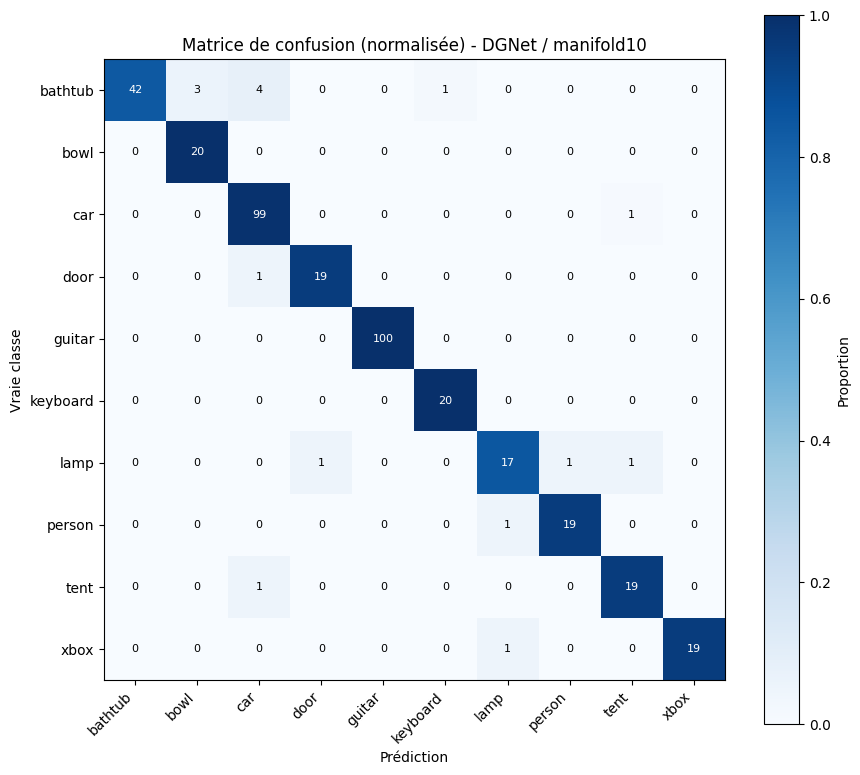

Matrice de confusion sauvegardée : /kaggle/working/manifold10_training_output/confusion_matrix.png

=== Métriques de classification ===
Accuracy          : 0.9590
Precision (macro) : 0.9464
Recall (macro)    : 0.9480
F1-score (macro)  : 0.9458

              precision    recall  f1-score   support

     bathtub       1.00      0.84      0.91        50
        bowl       0.87      1.00      0.93        20
         car       0.94      0.99      0.97       100
        door       0.95      0.95      0.95        20
      guitar       1.00      1.00      1.00       100
    keyboard       0.95      1.00      0.98        20
        lamp       0.89      0.85      0.87        20
      person       0.95      0.95      0.95        20
        tent       0.90      0.95      0.93        20
        xbox       1.00      0.95      0.97        20

    accuracy                           0.96       390
   macro avg       0.95      0.95      0.95       390
weighted avg       0.96      0.96      0.96       3

In [55]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, classification_report,
)

CLASS_NAMES = [
    "bathtub", "bowl", "car", "door", "guitar",
    "keyboard", "lamp", "person", "tent", "xbox",
]

predictions_data = np.load(MANIFOLD10_TRAINING_OUTPUT_DIR / "final_predictions.npz")
y_pred = predictions_data["predictions"]
y_true = predictions_data["labels"]

cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vraie classe")
ax.set_title("Matrice de confusion (normalisée) - DGNet / manifold10")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        text_color = "white" if cm_normalized[i, j] > 0.5 else "black"
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color=text_color, fontsize=8)

fig.colorbar(im, ax=ax, label="Proportion")
plt.tight_layout()
cm_path = MANIFOLD10_TRAINING_OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print("Matrice de confusion sauvegardée :", cm_path)

accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

classification_metrics = {
    "accuracy": float(accuracy),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "precision_weighted": float(precision_weighted),
    "recall_weighted": float(recall_weighted),
    "f1_weighted": float(f1_weighted),
}

with open(MANIFOLD10_TRAINING_OUTPUT_DIR / "classification_metrics.json", "w", encoding="utf-8") as f:
    json.dump(classification_metrics, f, indent=2)

print("\n=== Métriques de classification ===")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision (macro) : {precision_macro:.4f}")
print(f"Recall (macro)    : {recall_macro:.4f}")
print(f"F1-score (macro)  : {f1_macro:.4f}")
print("\n" + classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

In [56]:
with open(MANIFOLD10_TRAINING_OUTPUT_DIR / "training_info.json") as f:
    training_info = json.load(f)
with open(MANIFOLD10_TRAINING_OUTPUT_DIR / "computational_metrics.json") as f:
    computational_metrics = json.load(f)

per_class_lines = []
for class_index, class_name in enumerate(CLASS_NAMES):
    class_mask = (y_true == class_index)
    class_count = int(class_mask.sum())
    class_correct = int((y_pred[class_mask] == class_index).sum())
    class_acc = class_correct / class_count if class_count > 0 else 0.0
    per_class_lines.append(f"| {class_name} | {class_count} | {class_correct} | {class_acc:.3f} |")

report_content = f"""# Rapport d'expérience — DGNet sur manifold10

## 1. Contexte

Dataset remplacé par l'encadrant : `manifold10` au lieu de ModelNet10 Original.
10 classes différentes (bathtub, bowl, car, door, guitar, keyboard, lamp, person,
tent, xbox), maillages déjà propres et watertight (nom "manifold"), format .obj,
1254 train / 390 test.

## 2. Architecture et modifications

Mêmes correctifs documentés que pour ModelNet10/SHREC16 (cahier des charges §5.1) :
tête de classification ajoutée, radius=[None,0.2,0.4,0.8], SpatialConv.execute
patché (matmul), normalisation des sommets, environnement Python 3.10.

Contrairement à ModelNet10 original, **aucune simplification géométrique n'a été
nécessaire** : les maillages manifold10 vont de 498 à 2718 faces (médiane 500),
largement gérable directement par la pyramide DGNet.

## 3. Configuration d'entraînement

| Paramètre | Valeur |
|---|---|
| Nombre d'epochs | {training_info['num_epochs']} |
| Batch size | {training_info['batch_size']} |
| Optimiseur | {training_info['optimizer']} |
| Learning rate initial | {training_info['learning_rate']} |
| Scheduler | {training_info['lr_scheduler']} |
| Weight decay | {training_info['weight_decay']} |
| Dropout (tête classification) | 0.3 |
| Hardware | {computational_metrics['gpu_name']} |
| Taille train / test | {training_info['train_size']} / {training_info['test_size']} |
| Durée totale d'entraînement | {training_info['total_training_time_seconds']/60:.1f} min |
| Meilleure epoch | {training_info['best_epoch']} |

## 4. Résultats

| Métrique | Valeur |
|---|---|
| Accuracy | {classification_metrics['accuracy']:.4f} |
| Precision (macro) | {classification_metrics['precision_macro']:.4f} |
| Recall (macro) | {classification_metrics['recall_macro']:.4f} |
| F1-score (macro) | {classification_metrics['f1_macro']:.4f} |
| Nombre de paramètres | {computational_metrics['num_parameters']:,} |
| Temps d'inférence | {computational_metrics['avg_inference_time_ms_steady_state']:.2f} ms |

### Accuracy par classe

| Classe | Nb. échantillons | Corrects | Accuracy |
|---|---|---|---|
{chr(10).join(per_class_lines)}

## 5. Comparaison avec les autres datasets DGNet du projet

| Dataset | Accuracy | Notes |
|---|---|---|
| ModelNet10 Original | 70,5% | Maillages non-manifold, simplification Open3D nécessaire |
| SHREC16 Original | 64,2% | Seulement 16 exemples/classe, dropout ajusté |
| manifold10 | {classification_metrics['accuracy']:.1%} | Maillages propres, ~125 exemples/classe |

## 6. Reproductibilité

- Seed aléatoire : {training_info['random_seed']}
- Checkpoints : `checkpoints/best_model.pkl`, `checkpoints/final_model.pkl`
- Historique complet : `training_history.csv`
- Prédictions finales (test) : `final_predictions.npz`
"""

report_path = MANIFOLD10_TRAINING_OUTPUT_DIR / "RAPPORT_DGNet_manifold10.md"
report_path.write_text(report_content, encoding="utf-8")
print("Rapport écrit :", report_path)

Rapport écrit : /kaggle/working/manifold10_training_output/RAPPORT_DGNet_manifold10.md
